<a href="https://colab.research.google.com/github/Praveenkumarr007/HPSC_Assignment_1/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Artist is reading the notebook...
Success! Graph saved as my_freefall_plot.png


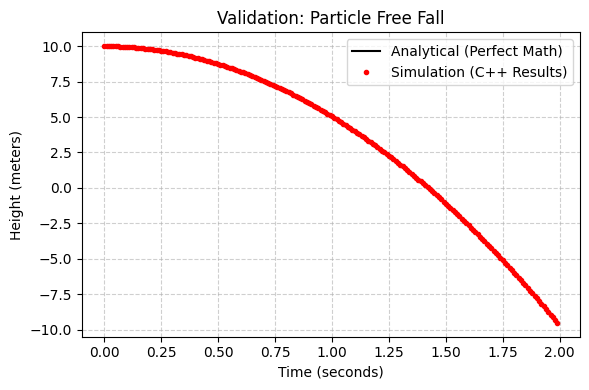

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("Artist is reading the notebook...")

# 1. Read the CSV file you just made
df = pd.read_csv('data_freefall.csv')

# 2. Set up the canvas
plt.figure(figsize=(6, 4))

# 3. Draw the lines
# The black line is the perfect math equation
plt.plot(df['Time'], df['Z_analytical'], 'k-', label='Analytical (Perfect Math)')
# The red dots are the numbers your C++ code calculated
plt.plot(df['Time'], df['Z_numerical'], 'r.', label='Simulation (C++ Results)')

# 4. Add titles and labels (Publication Quality!)
plt.xlabel('Time (seconds)')
plt.ylabel('Height (meters)')
plt.title('Validation: Particle Free Fall')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 5. Save the final picture
plt.tight_layout()
plt.savefig('my_freefall_plot.png', dpi=300)

print("Success! Graph saved as my_freefall_plot.png")
plt.show()

Artist is reading the bounce notebook...
Success! Graph saved as my_bounce_plot.png


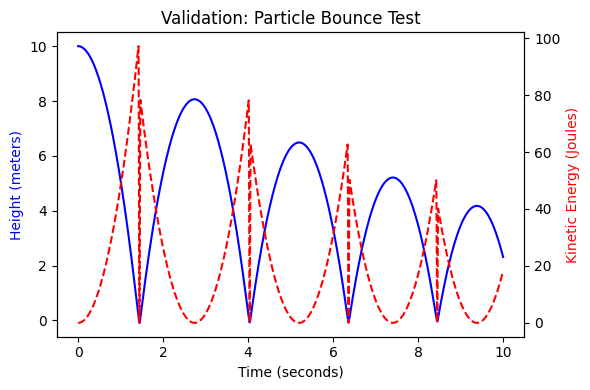

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("Artist is reading the bounce notebook...")

# 1. Read the CSV file you just made from C++
df = pd.read_csv('data_bounce.csv')

# 2. Set up the canvas
fig, ax1 = plt.subplots(figsize=(6, 4))

# 3. Draw the Height line (Blue)
ax1.plot(df['Time'], df['Height'], 'b-', label='Height')
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Height (meters)', color='b')

# 4. Draw the Kinetic Energy line (Red dashed)
ax2 = ax1.twinx()
ax2.plot(df['Time'], df['KineticEnergy'], 'r--', label='Kinetic Energy')
ax2.set_ylabel('Kinetic Energy (Joules)', color='r')

# 5. Add a title and save it!
plt.title('Validation: Particle Bounce Test')
plt.tight_layout()
plt.savefig('my_bounce_plot.png', dpi=300)

print("Success! Graph saved as my_bounce_plot.png")
plt.show()

Artist is drawing the final OpenMP graphs...
-> Performance graph saved as 'plot_performance.png'
-> 3D Snapshot saved as 'plot_snapshot.png'


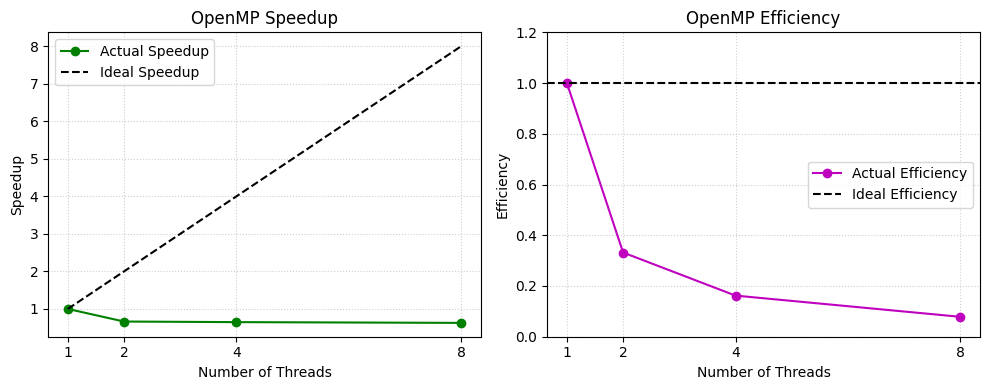

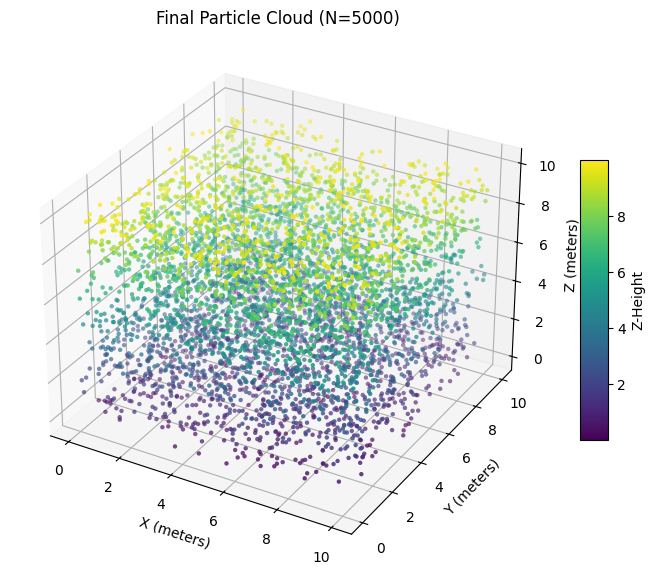

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("Artist is drawing the final OpenMP graphs...")

# ==========================================
# GRAPH 1: OPENMP PERFORMANCE (Figure 3)
# ==========================================
# Read the performance notebook
df_perf = pd.read_csv('data_performance.csv')

# Create a wide canvas for two side-by-side graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Left Graph: Speedup
ax1.plot(df_perf['Threads'], df_perf['Speedup'], 'go-', label='Actual Speedup')
ax1.plot(df_perf['Threads'], df_perf['Threads'], 'k--', label='Ideal Speedup') # The perfect scenario
ax1.set_xlabel('Number of Threads')
ax1.set_ylabel('Speedup')
ax1.set_title('OpenMP Speedup')
ax1.set_xticks(df_perf['Threads'])
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# Right Graph: Efficiency
ax2.plot(df_perf['Threads'], df_perf['Efficiency'], 'mo-', label='Actual Efficiency')
ax2.axhline(1.0, color='k', linestyle='--', label='Ideal Efficiency') # 1.0 means 100% efficient
ax2.set_xlabel('Number of Threads')
ax2.set_ylabel('Efficiency')
ax2.set_title('OpenMP Efficiency')
ax2.set_xticks(df_perf['Threads'])
ax2.set_ylim([0, 1.2])
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('plot_performance.png', dpi=300)
print("-> Performance graph saved as 'plot_performance.png'")


# ==========================================
# GRAPH 2: 3D PARTICLE CLOUD (Snapshot)
# ==========================================
# Read the snapshot notebook
df_snap = pd.read_csv('data_snapshot_final.csv')

fig_3d = plt.figure(figsize=(7, 6))
ax3d = fig_3d.add_subplot(111, projection='3d')

# Draw the particles as a 3D scatter plot. Color them based on their Z (height) value!
scatter = ax3d.scatter(df_snap['X'], df_snap['Y'], df_snap['Z'],
                       c=df_snap['Z'], cmap='viridis', s=10, edgecolors='none')

ax3d.set_xlabel('X (meters)')
ax3d.set_ylabel('Y (meters)')
ax3d.set_zlabel('Z (meters)')
ax3d.set_title('Final Particle Cloud (N=5000)')

# Add a colorbar on the side
plt.colorbar(scatter, shrink=0.5, aspect=10, label='Z-Height')

plt.tight_layout()
plt.savefig('plot_snapshot.png', dpi=300)
print("-> 3D Snapshot saved as 'plot_snapshot.png'")

plt.show()

Success! Plot saved successfully as error_vs_dt.pdf and error_vs_dt.png


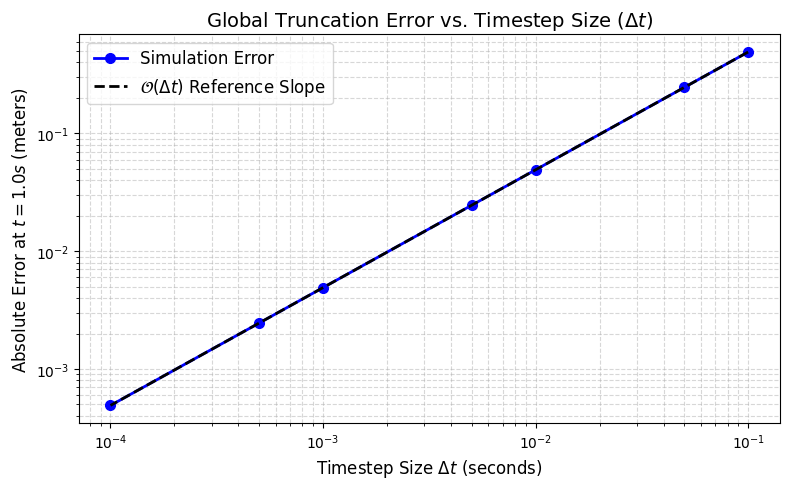

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the simulation parameters
dt_values = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
t_end = 1.0
g = -9.81

# Analytical exact solution at t = 1.0s
y_exact = 0.5 * g * (t_end ** 2)

errors = []

# 2. Run the Semi-Implicit Euler simulation for each timestep size
for dt in dt_values:
    y = 0.0
    vy = 0.0
    t = 0.0

    while t < t_end - 1e-9: # small tolerance for floating point math
        # Ensure we don't overshoot the end time
        current_dt = min(dt, t_end - t)

        # Semi-implicit Euler integration
        vy += g * current_dt
        y += vy * current_dt
        t += current_dt

    # Calculate absolute error
    error = abs(y_exact - y)
    errors.append(error)

# 3. Create Publication-Quality Log-Log Plot
plt.figure(figsize=(8, 5))

# Plot the actual simulation error
plt.loglog(dt_values, errors, 'bo-', linewidth=2, markersize=7, label='Simulation Error')

# Plot a reference line for O(dt) to prove 1st-order accuracy
# We scale the reference line to start at the same point as our data
ref_y = [dt * (errors[0] / dt_values[0]) for dt in dt_values]

# NOTICE THE 'r' ADDED BEFORE THE STRINGS BELOW:
plt.loglog(dt_values, ref_y, 'k--', linewidth=2, label=r'$\mathcal{O}(\Delta t)$ Reference Slope')

# Formatting for IEEE paper
plt.title(r'Global Truncation Error vs. Timestep Size ($\Delta t$)', fontsize=14)
plt.xlabel(r'Timestep Size $\Delta t$ (seconds)', fontsize=12)
plt.ylabel(r'Absolute Error at $t=1.0s$ (meters)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()

# Save the figure
plt.savefig('error_vs_dt.pdf', dpi=300)
plt.savefig('error_vs_dt.png', dpi=300)
print("Success! Plot saved successfully as error_vs_dt.pdf and error_vs_dt.png")

plt.show()